# Sintesi degli spettri

Training supervised, vanno assegnate delle labels agli spettri. Ad ogni spettro assocerei **numero di picchi** e **posizioni dei picchi**. 

### Individuare i picchi con scipy

In [1]:
import numpy as np
from scipy.signal import find_peaks

def trova_dip_scipy(frequenze, spettro, soglia=-0.1):
    """
    Trova i dip (minimi) in uno spettro usando scipy.
    frequenze: asse x (es. array da 750 elementi)
    spettro: asse y (es. array da 750 elementi)
    soglia: valore sotto il quale considerare valido il dip
    """
    # find_peaks cerca i massimi, quindi invertiamo lo spettro
    # La soglia diventa positiva per la ricerca dei massimi
    indici_picchi, info = find_peaks(
        -spettro, 
        height=-soglia,
        prominence=0.00001,  # Prominenza minima del picco
        width=1 # Utile perché è la stima del gamma della lorentziana
    )
    
    # Estraiamo le posizioni in frequenza
    posizioni = frequenze[indici_picchi]
    
    return posizioni, info

def trova_picchi_scipy(frequenze, spettro, soglia=-0.1):
    """
    Trova i picchi in uno spettro usando scipy.
    frequenze: asse x (es. array da 750 elementi)
    spettro: asse y (es. array da 750 elementi)
    soglia: valore sotto il quale considerare valido il picco
    """
    # find_peaks cerca i massimi, quindi invertiamo lo spettro
    # La soglia diventa positiva per la ricerca dei massimi
    indici_picchi, info = find_peaks(
        spettro, 
        height=soglia,
        prominence=0.00001,  # Prominenza minima del picco
        width=1 # Utile perché è la stima del gamma della lorentziana
    )
    
    # Estraiamo le posizioni in frequenza
    posizioni = frequenze[indici_picchi]
    
    return posizioni, info

In [ ]:
# Spettri
s = np.load('../data/50k/X_spectra_50k.npy')#, mmap_mode='r')
# Corrispondenti campi magnetici
B = np.load('../data/50k/Y_B_field_50k.npy')
# Asse x (frequenze)
f = np.arange(2500, 3250) 
x_axis = range(2500, 3250)

N_spettri, N_punti = s.shape[0], s.shape[1]

Cerco i picchi

In [3]:
# Liste per salvare i risultati di tutti gli spettri
num_picchi_totale = []
posizioni_totali = []
info_totale = [] 

for i in range(N_spettri):
    spettro_corrente = s[i]
    pos, info = trova_dip_scipy(f, spettro_corrente, soglia=-0.02)
    
    num_picchi_totale.append(len(pos))
    posizioni_totali.append(pos)
    info_totale.append(info)

In [10]:
for idx, n in enumerate(num_picchi_totale):
    if n == 8:
        print(idx)

Subito vediamo, nello spettro 2, un possibile problema. Lì ci sono chiaramente quattro dip, ma find_peaks non riesce a riconoscere quella spalla come un picco.

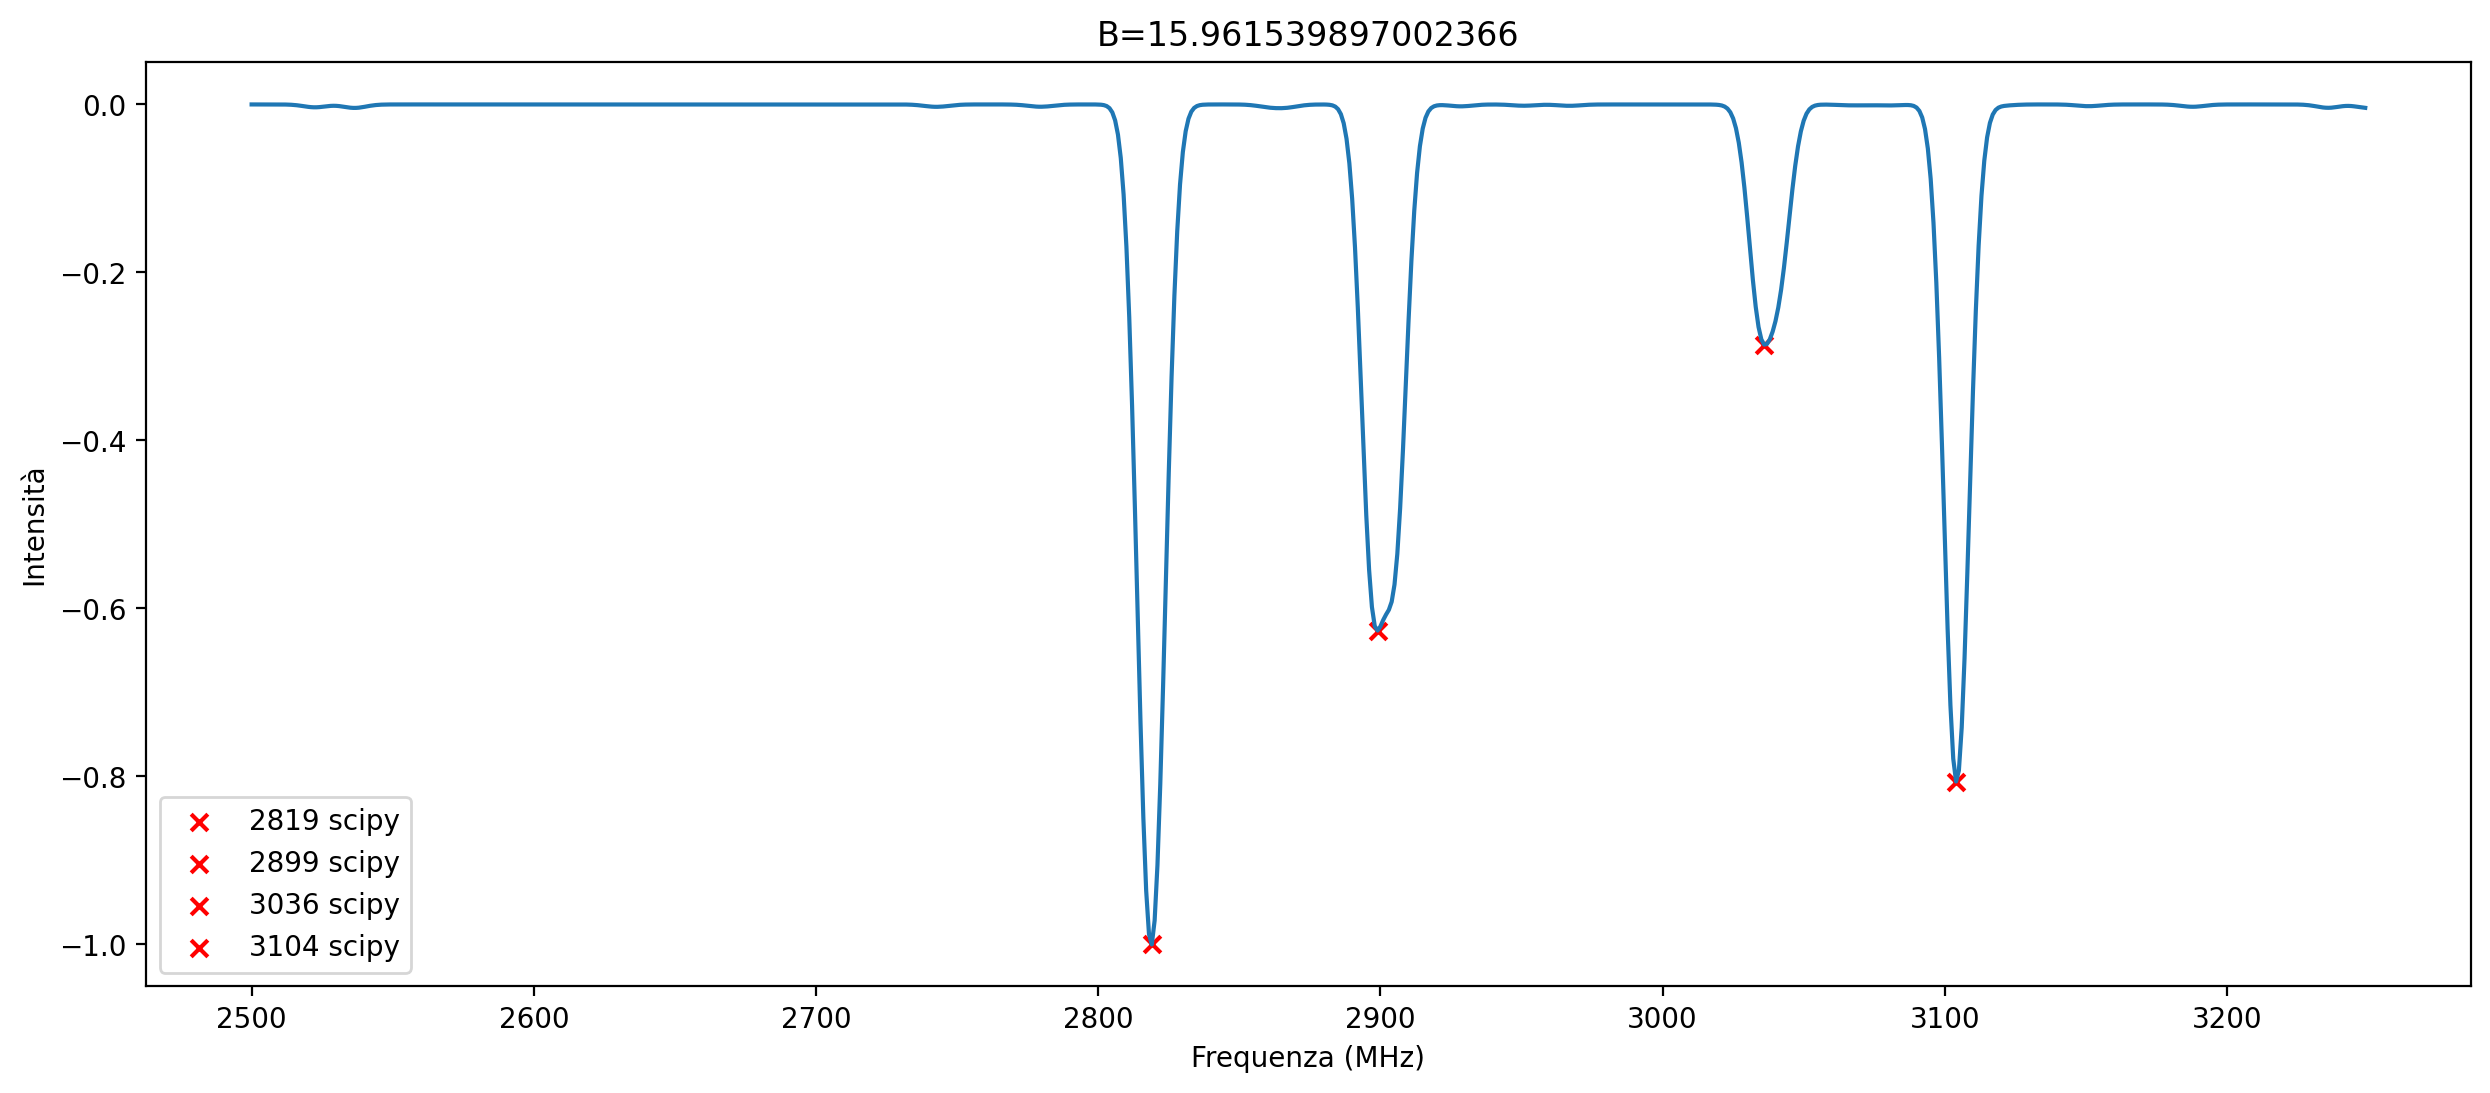

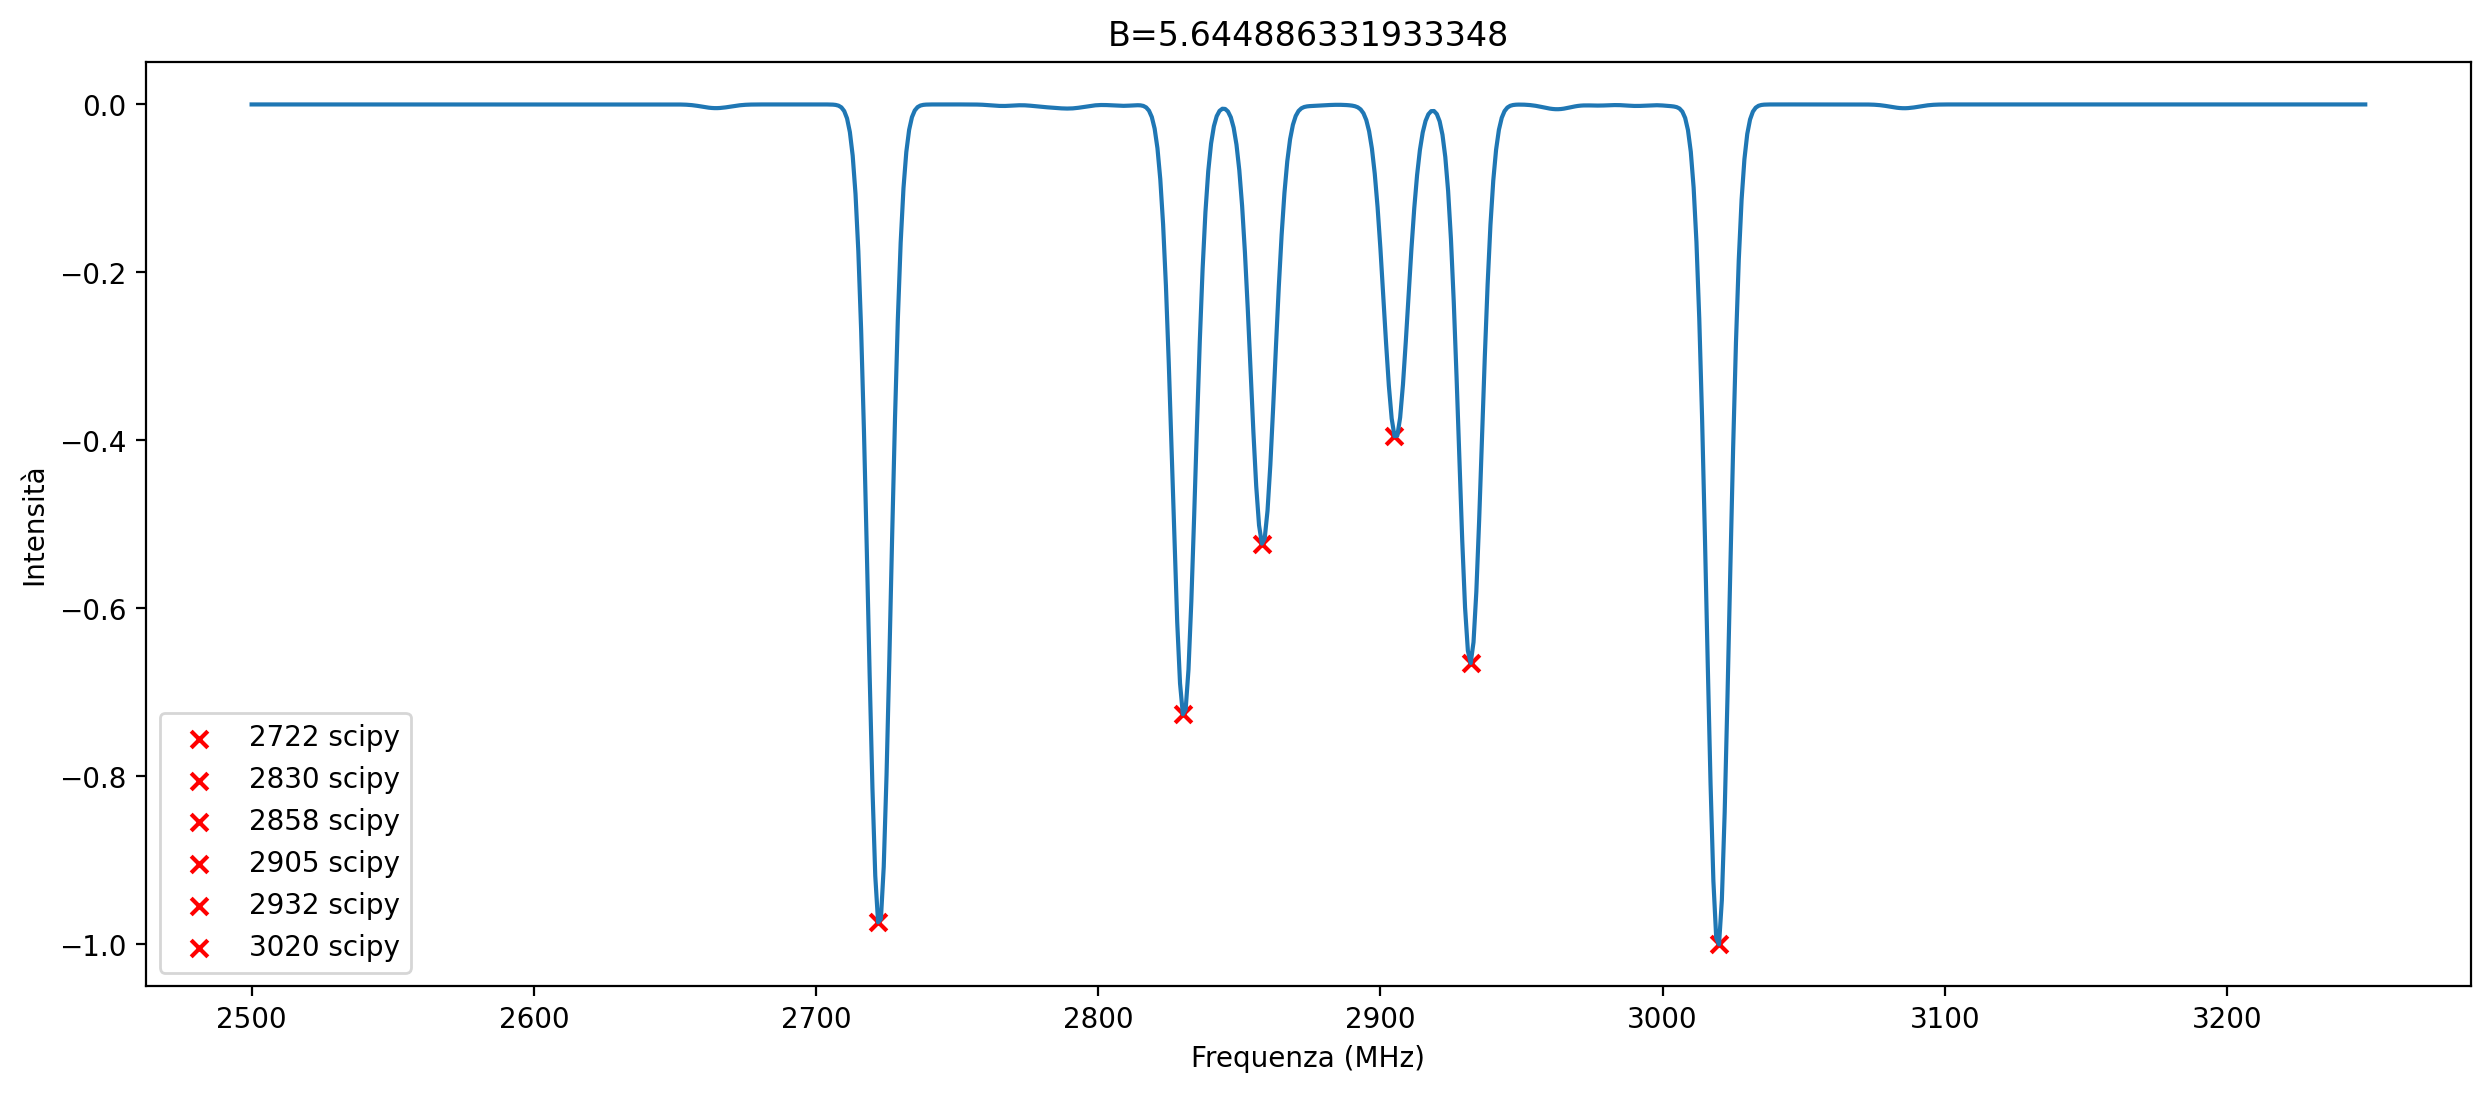

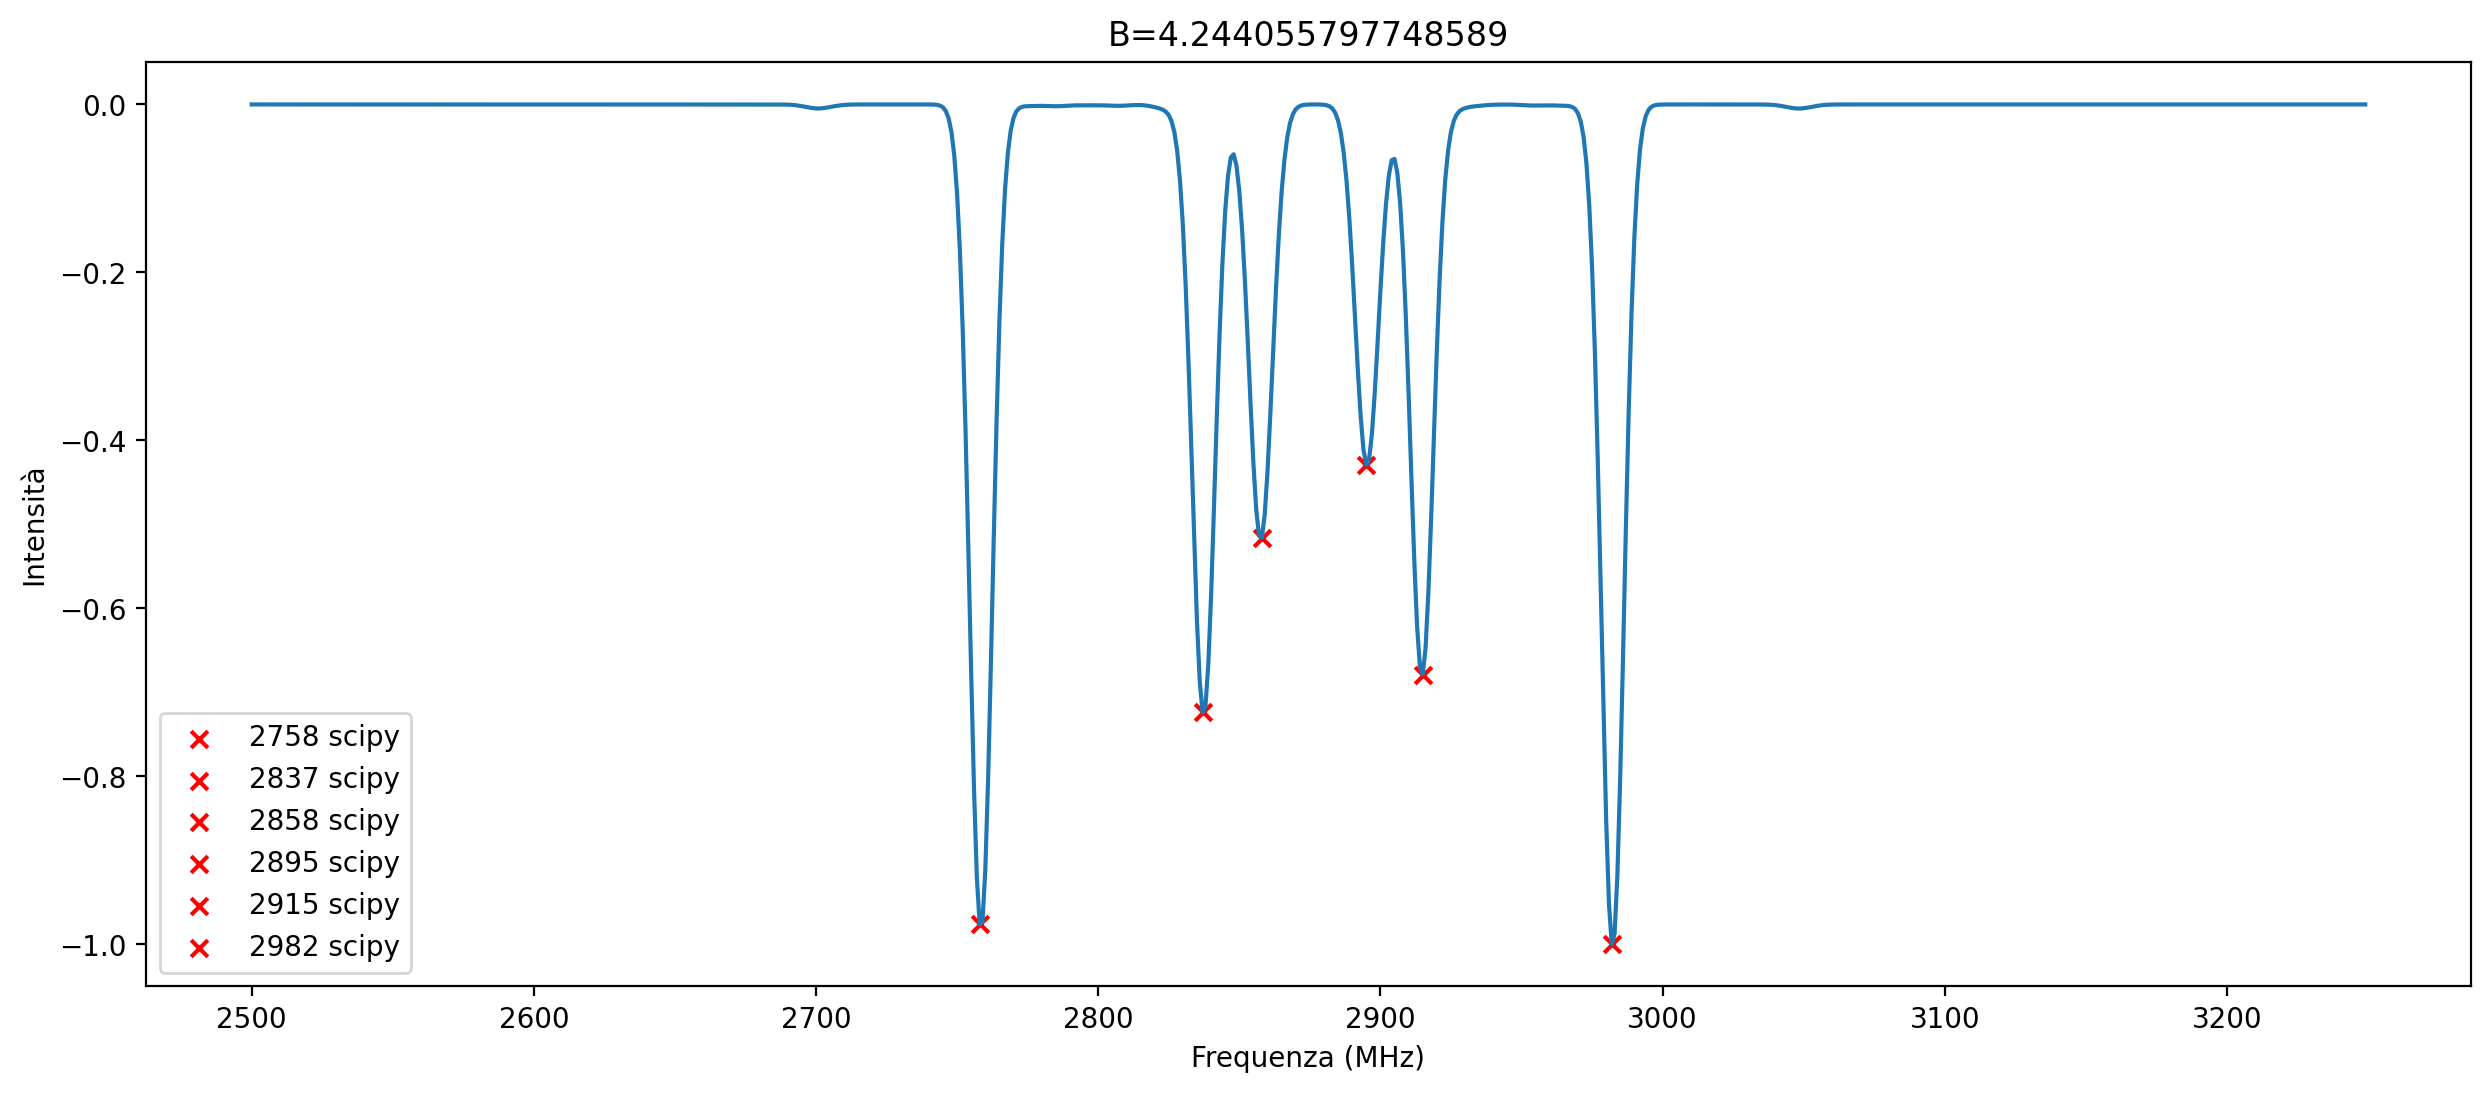

In [11]:
import matplotlib.pyplot as plt

for k in range(22, 25):  # Visualizziamo i primi 10 spettri
    plt.figure(figsize=(15, 6), dpi=200)
    plt.plot(x_axis, s[k])
    for pos in posizioni_totali[k]:
        h = info_totale[k]['peak_heights'][np.where(posizioni_totali[k] == pos)[0][0]]
        plt.scatter(pos, -h, color='red', marker='x', label=f'{pos} scipy')  # Evidenziamo i picchi
    plt.title(f"B={B[k]}")
    plt.xlabel('Frequenza (MHz)')
    plt.ylabel('Intensità')
    plt.legend()
    plt.show()

### Come sistemare?

---

provo a cercare le spalle nelle derivate dello spettro

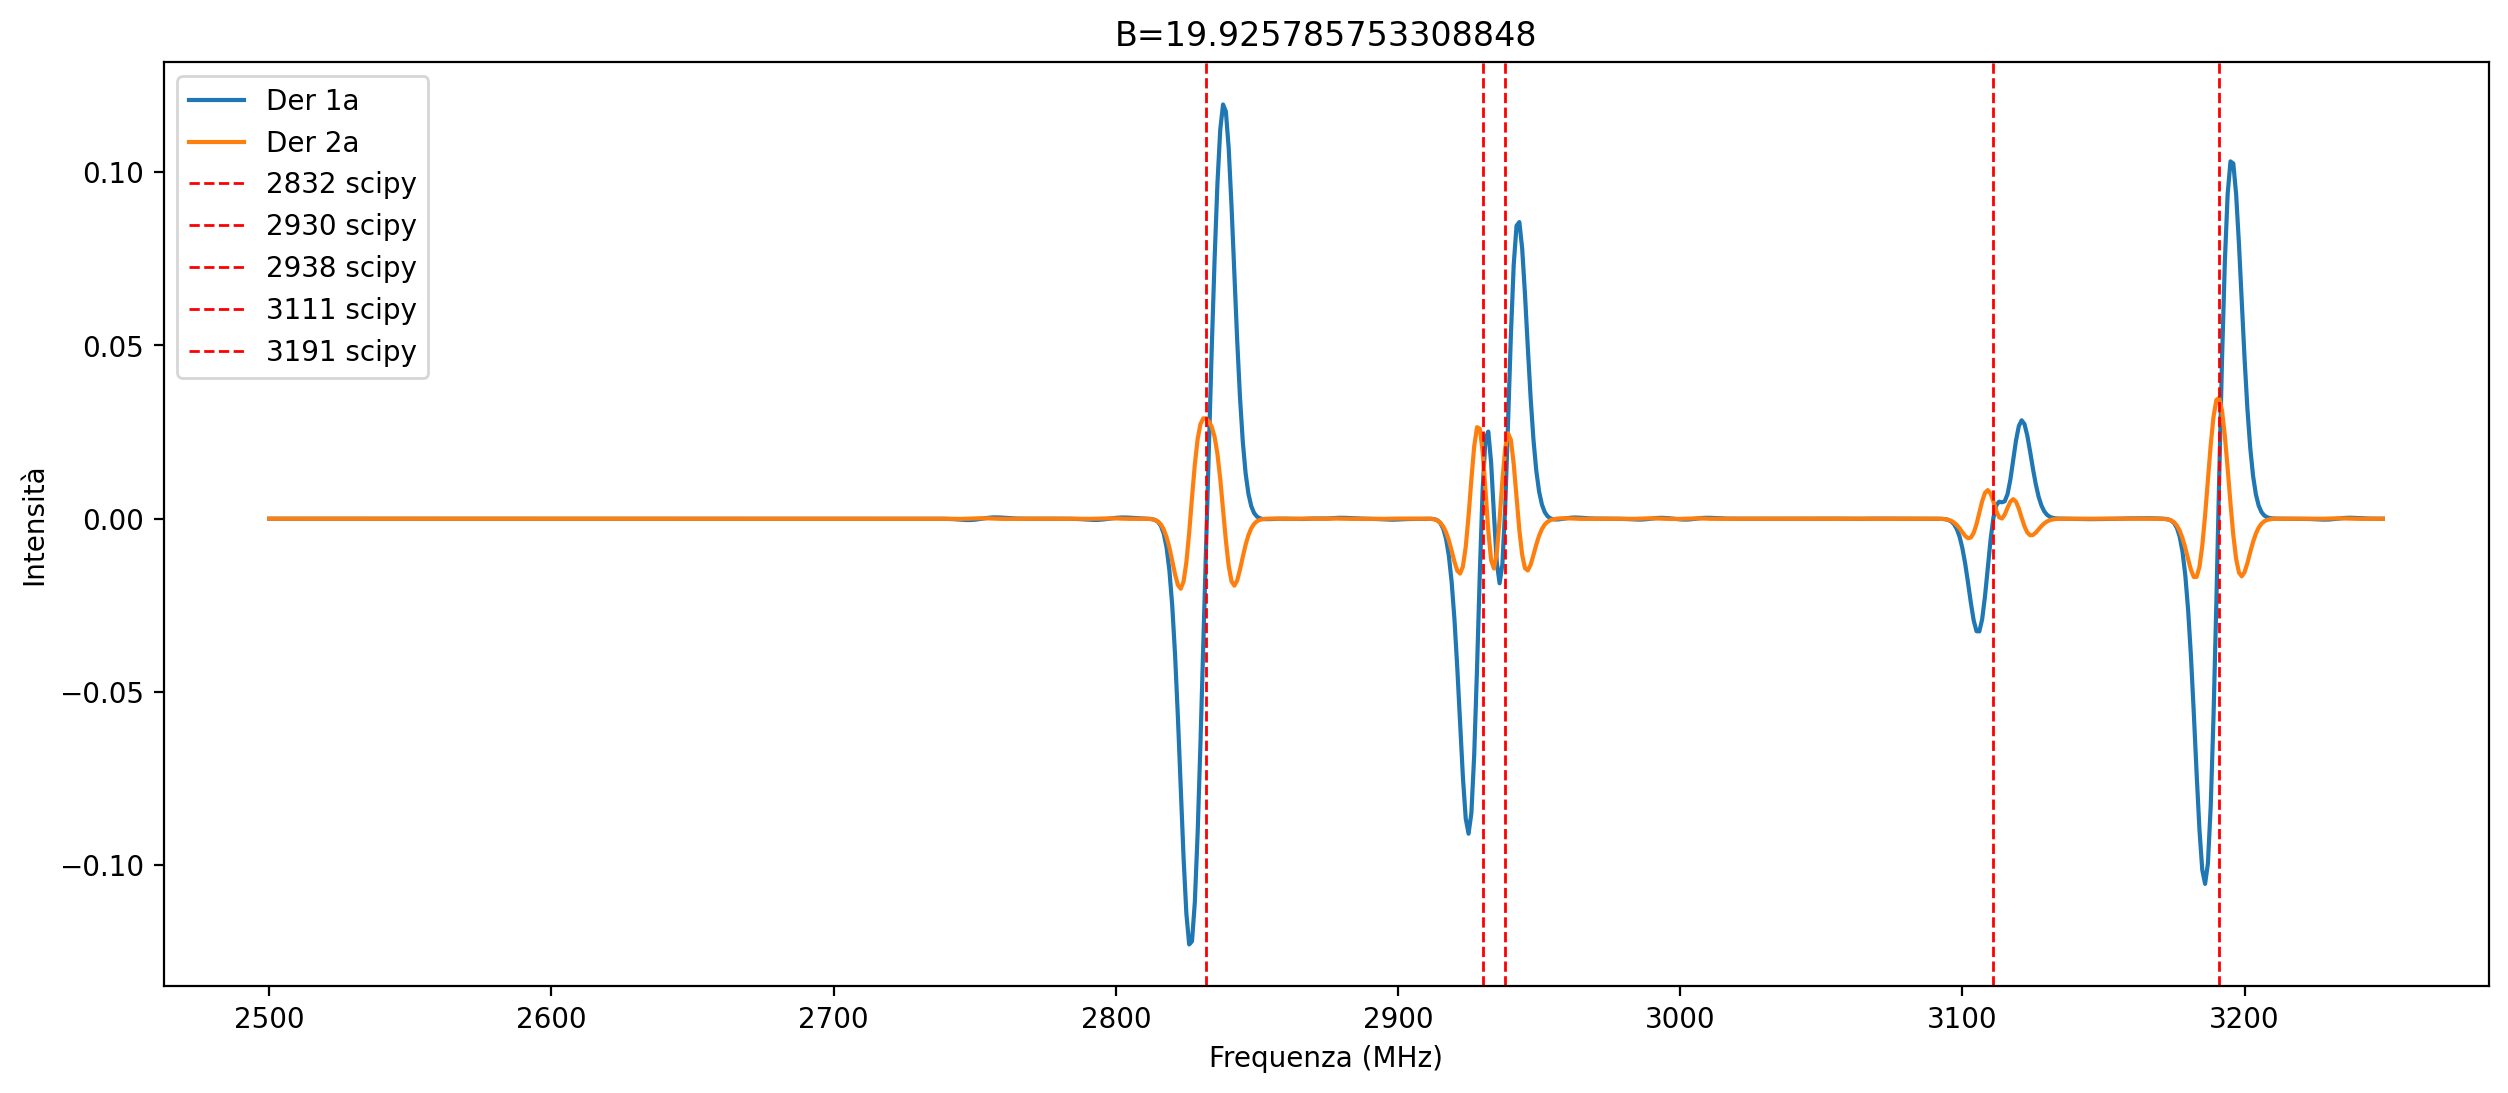

In [5]:
ds_df = np.gradient(s[2], f)
d2s_df2 = np.gradient(ds_df, f)

plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, ds_df, label='Der 1a')
plt.plot(x_axis, d2s_df2, label='Der 2a')
for pos in posizioni_totali[2]:
    h = info_totale[2]['peak_heights'][np.where(posizioni_totali[2] == pos)[0][0]]
    #plt.scatter(pos, -h/7, color='red', marker='x', label=f'{pos} scipy')  # Evidenziamo i picchi
    plt.axvline(x=pos, color='red', linestyle='--', label=f'{pos} scipy', linewidth=1)  # Evidenziamo i picchi con linee verticali
plt.title(f"B={B[2]}")
plt.xlabel('Frequenza (MHz)')
plt.ylabel('Intensità')
plt.legend()
plt.show()

in teoria, i massimi della derivata seconda forniscono i picchi

In [6]:
pos_der2, info_der2 = trova_picchi_scipy(f, d2s_df2, soglia=0.001)

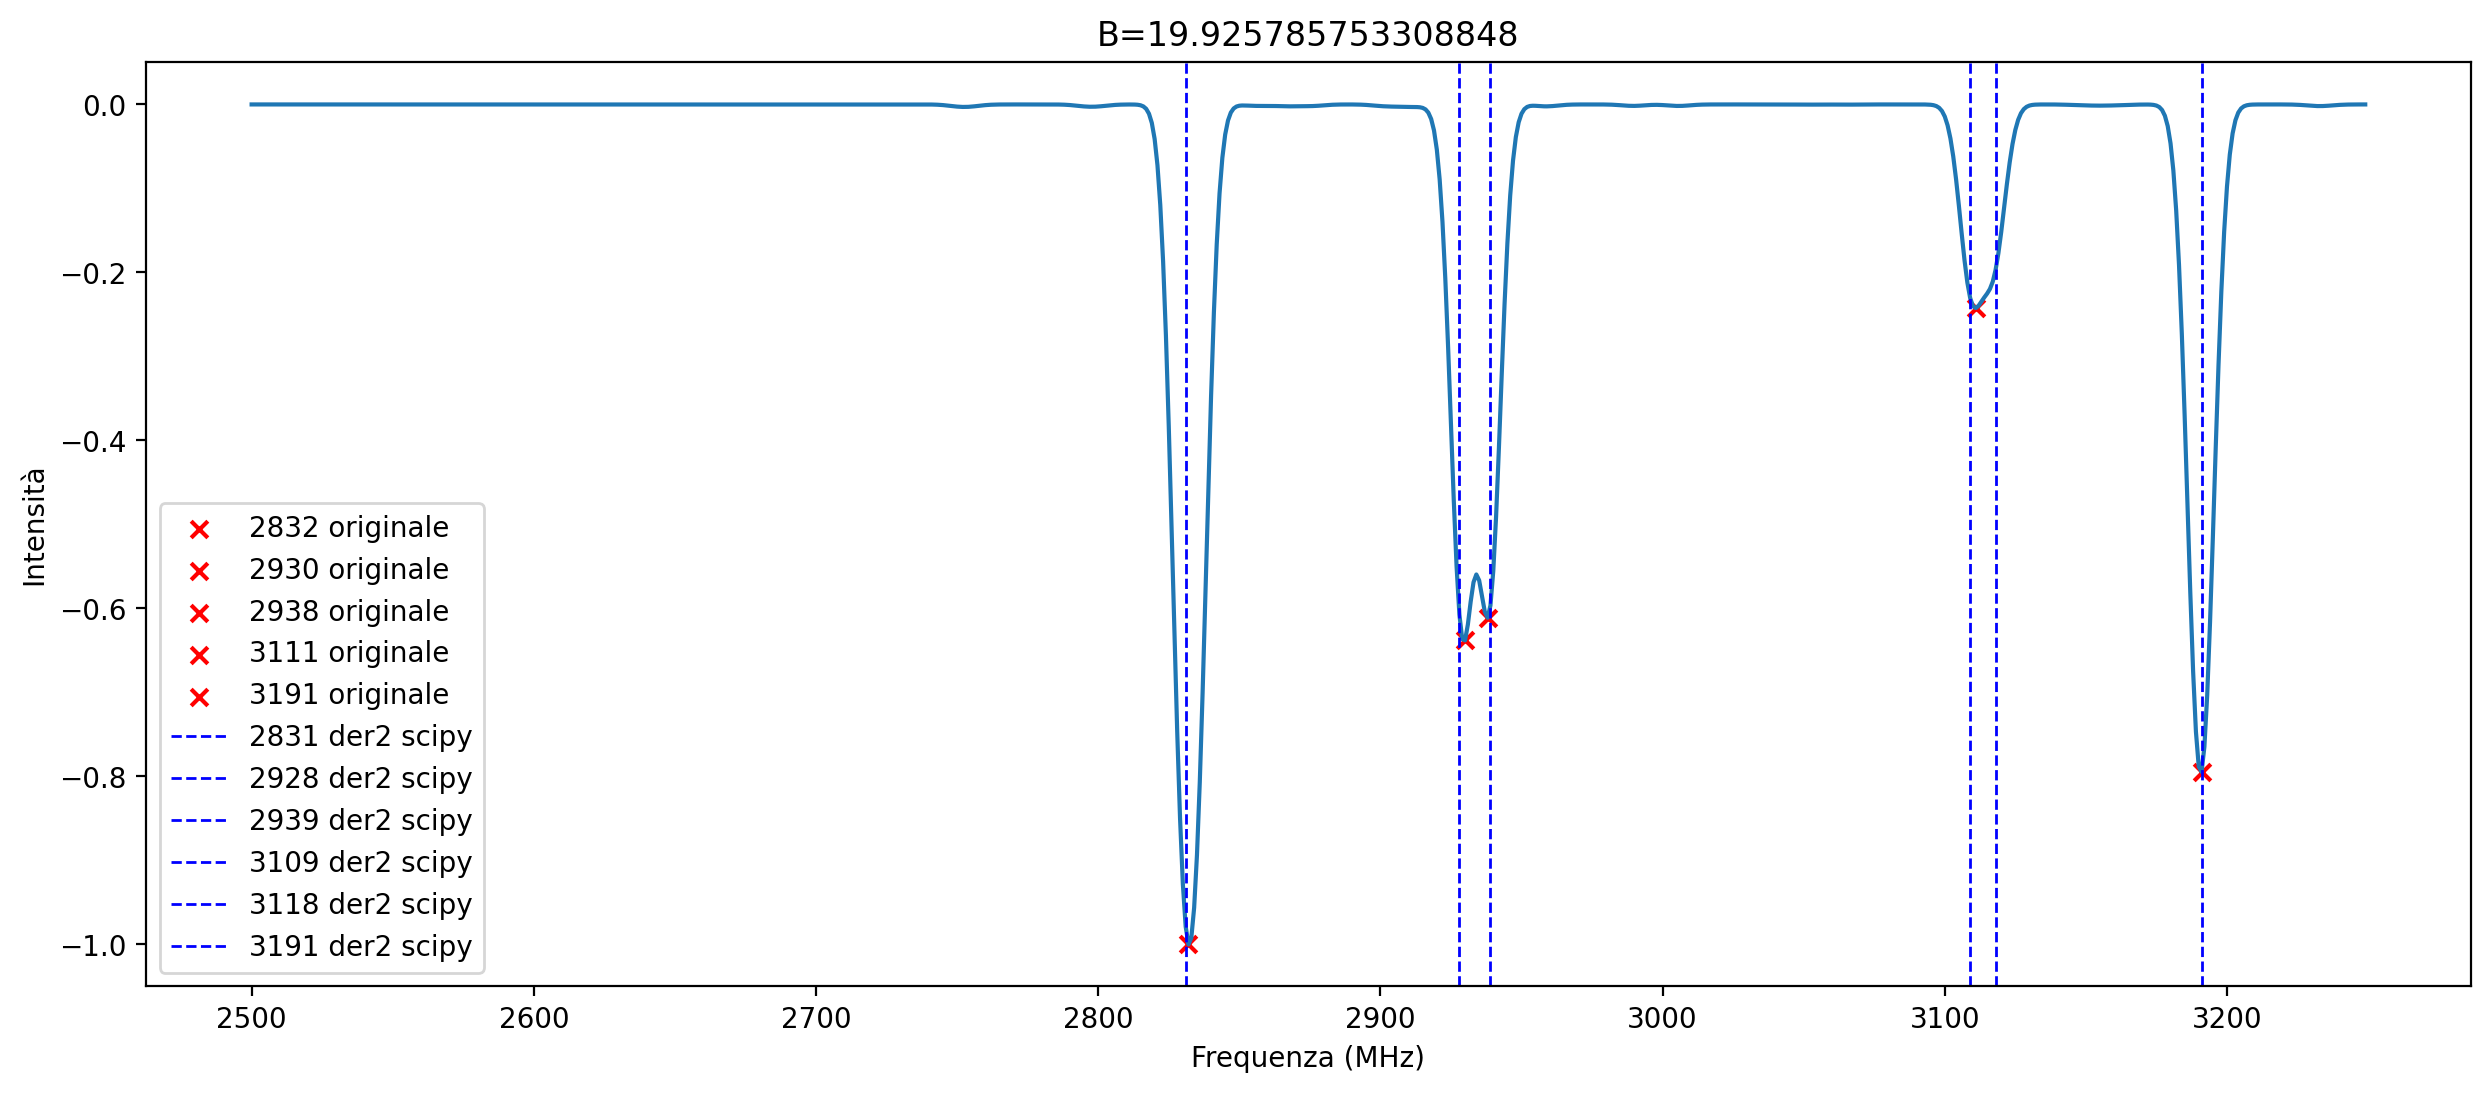

In [7]:
for k in range(2, 3):  # Visualizziamo i primi 10 spettri
    plt.figure(figsize=(15, 6), dpi=200)
    plt.plot(x_axis, s[k])
    for pos in posizioni_totali[k]:
        h = info_totale[k]['peak_heights'][np.where(posizioni_totali[k] == pos)[0][0]]
        plt.scatter(pos, -h, color='red', marker='x', label=f'{pos} originale')  # Evidenziamo i picchi
    for pos in pos_der2:
        plt.axvline(x=pos, color='blue', linestyle='--', label=f'{pos} der2 scipy', linewidth=1)  # Evidenziamo i picchi con linee verticali
    plt.title(f"B={B[k]}")
    plt.xlabel('Frequenza (MHz)')
    plt.ylabel('Intensità')
    plt.legend()
    plt.show()

### fit

---

Forse già qui si deve fare il fit multi-lorentziano. Bisogna assegnare un errore di qualche tipo allo spettro, in modo da avere un sistema per quantificare l'accordo tra fit e spettro. Se non c'è accordo, si può pensare «ehi, forse c'è da aggiungere una coppia di lorentziane»

Iniziamo col fittare lo spettro 2

In [8]:
from scipy.optimize import curve_fit
from assign_labels import multi_lorentziana, fit_spettro, fit_otto_lorentziane, otto_lorentziane

amp_2 = info_totale[2]['peak_heights']  # Ampiezze dei picchi per lo spettro 2
pos_2 = posizioni_totali[2]  # Posizioni dei picchi per lo spettro 2
gamma_2 = info_totale[2]['widths']  # Stima di gamma dalla larghezza del picco

# popt, pcov = curve_fit(multi_lorentziana, f, s[2], p0=[pos_2, gamma_2])

amp_2_opt, pos_2_opt, gamma_2_opt = fit_otto_lorentziane(f, s[2], amp_2, pos_2, gamma_2)

ValueError: Il numero di posizioni deve essere pari per poter duplicare i parametri.

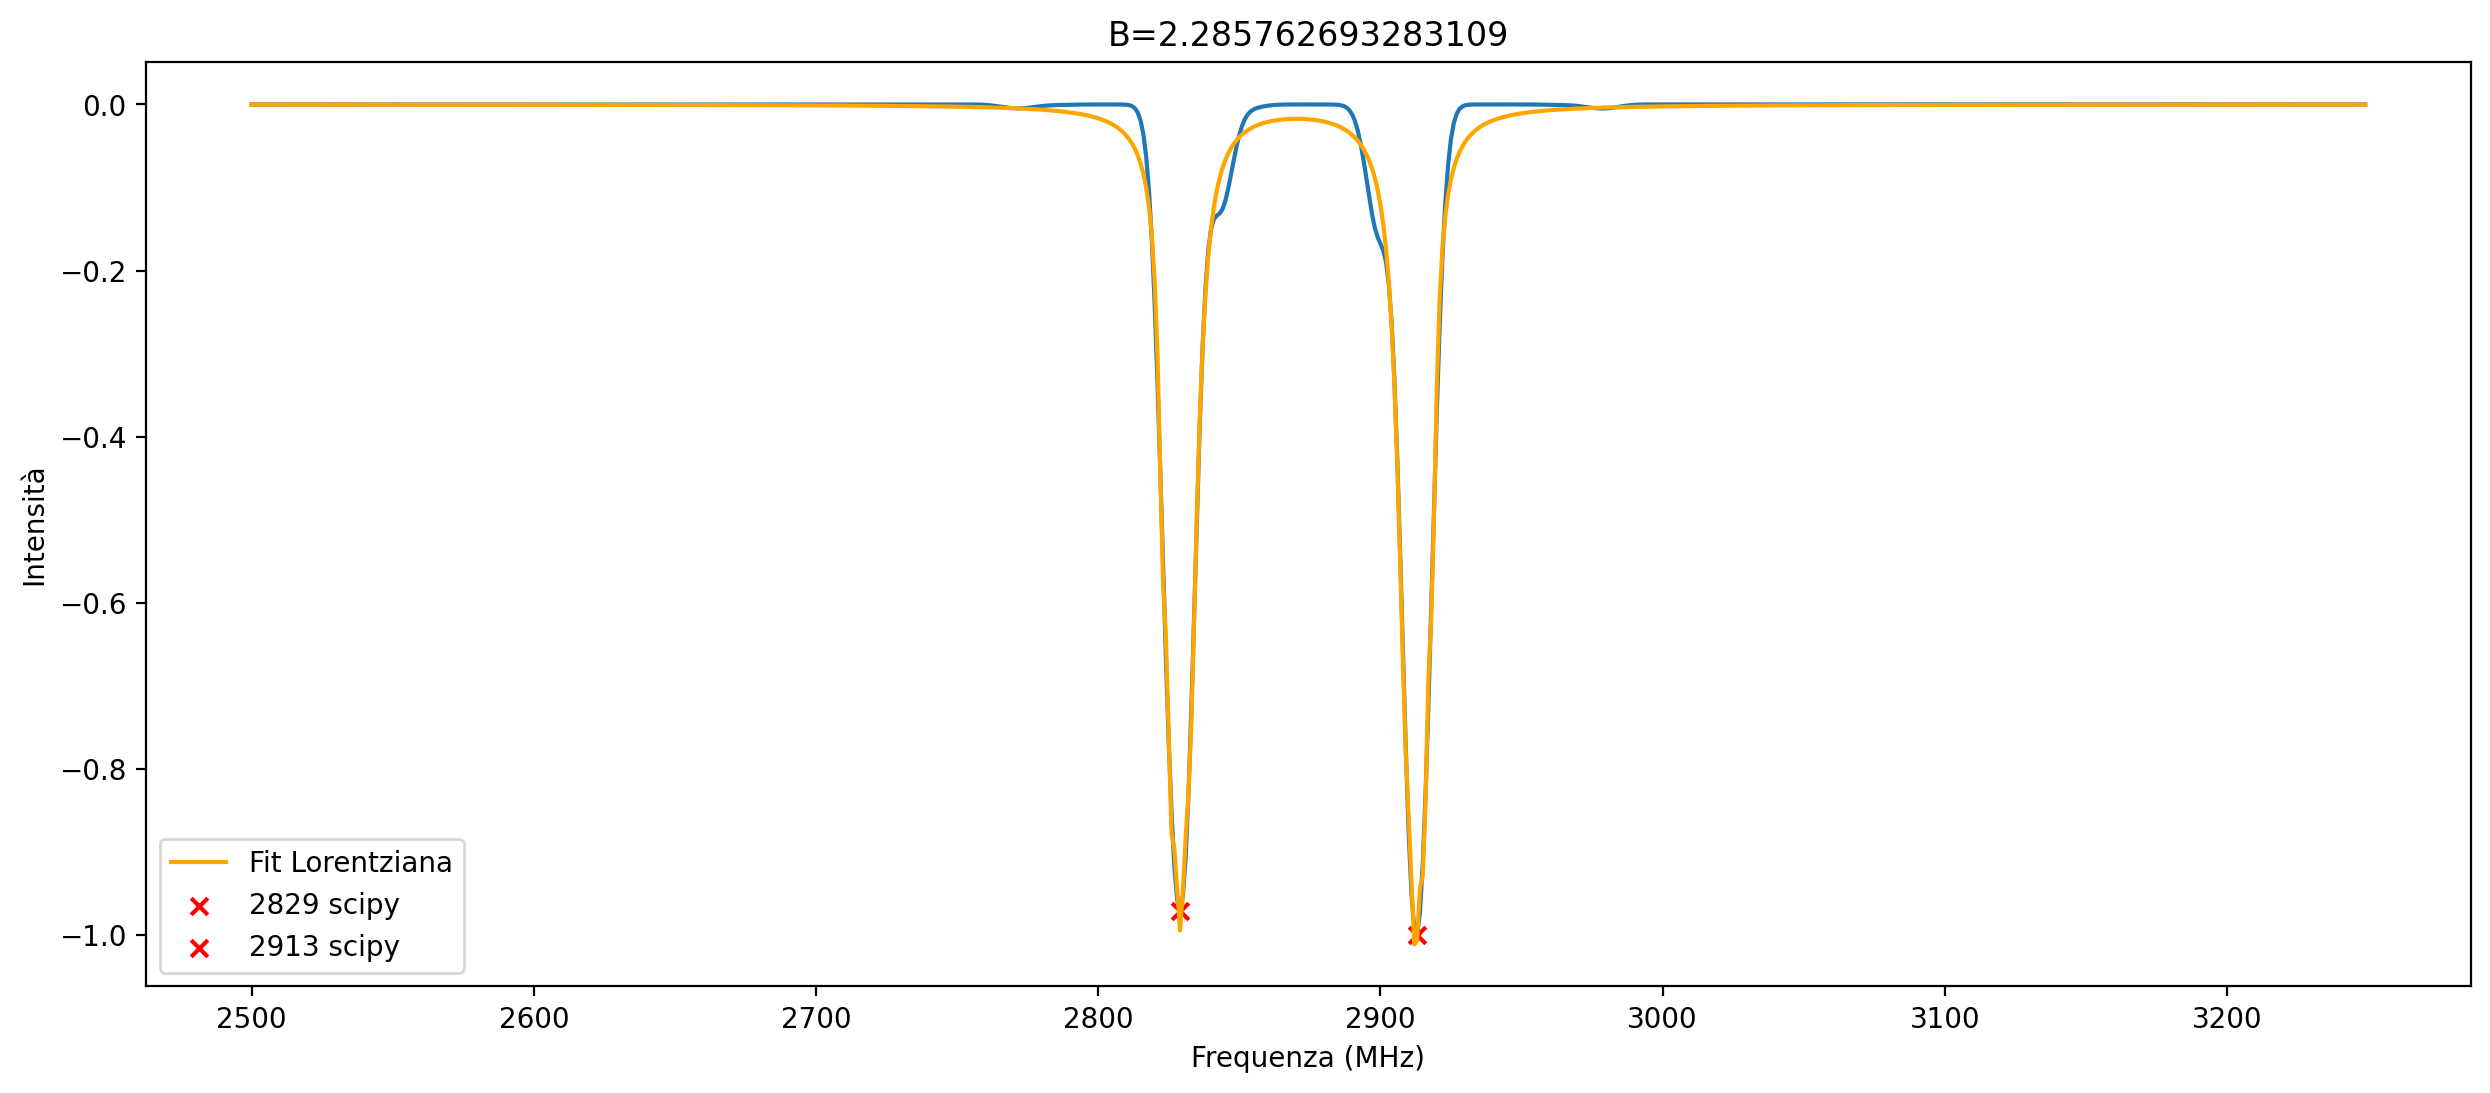

In [ ]:
plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, s[2])
plt.plot(x_axis, -otto_lorentziane(f, amp_2_opt, pos_2_opt, gamma_2_opt), color='orange', label='Fit Lorentziana')
for pos in posizioni_totali[2]:
    h = info_totale[2]['peak_heights'][np.where(posizioni_totali[2] == pos)[0][0]]
    plt.scatter(pos, -h, color='red', marker='x',label=f"{pos} scipy")  # Evidenziamo i picchi
plt.title(f"B={B[2]}")
plt.xlabel('Frequenza (MHz)')
plt.ylabel('Intensità')
plt.legend()
plt.show()

In [ ]:
# stampo i parametri ottimizzati
print("Ampiezze ottimizzate:", amp_2_opt)
print("Posizioni ottimizzate:", pos_2_opt)
print("Gamma ottimizzati:", gamma_2_opt)

Ampiezze ottimizzate: [0.90363658 0.48836853 2.12307068 1.29460571 0.49964094 2.22597652
 1.29143738 0.88393177]
Posizioni ottimizzate: [2825.85443885 2918.36454124 2832.41437917 2912.5272298  2822.88771353
 2909.1574209  2828.89855927 2915.47933865]
Gamma ottimizzati: [2.02336301 1.75702729 3.66913184 2.41917327 1.82710547 3.97150654
 2.43603396 1.94629751]


chiaramente non va bene, quindi l'algoritmo deve valutare e notare che non va mica bene

In [ ]:
# considero un errore poissoniano
sigma = np.sqrt(np.abs(s[2]))
min_non_zero = np.min(sigma[sigma > 0])  # Trova il minimo non zero
sigma = np.where(sigma == 0, min_non_zero, sigma)  # Evitiamo divisioni per zero

# calcolo somma quadratica dei residui normalizzata per i gradi di libertà 
# (chi quadro ridotto)
res = s[2] + multi_lorentziana(f, amp_2_opt, pos_2_opt, gamma_2_opt)
chi_2 = np.sum((res - s[2])**2 / sigma**2)
chi_2_rid = chi_2 / (len(f) - 2 * len(pos_2_opt))

print(f"Chi quadro ridotto: {chi_2_rid:.4f}")

Chi quadro ridotto: 14901.0563


### uso i picchi trovati con der2

In [ ]:
n_picchi_d2 = len(pos_der2)

amp_2_der2 = np.array([1]*n_picchi_d2)  # Ampiezze dei picchi per lo spettro 2
gamma_2_der2 = np.array([10]*n_picchi_d2)  # Stima di gamma dalla larghezza del picco

# popt, pcov = curve_fit(multi_lorentziana, f, s[2], p0=[pos_2, gamma_2])

amp_2_der2_opt, pos_2_der2_opt, gamma_2_der2_opt = fit_spettro(f, s[2], amp_2_der2, pos_der2, gamma_2_der2)

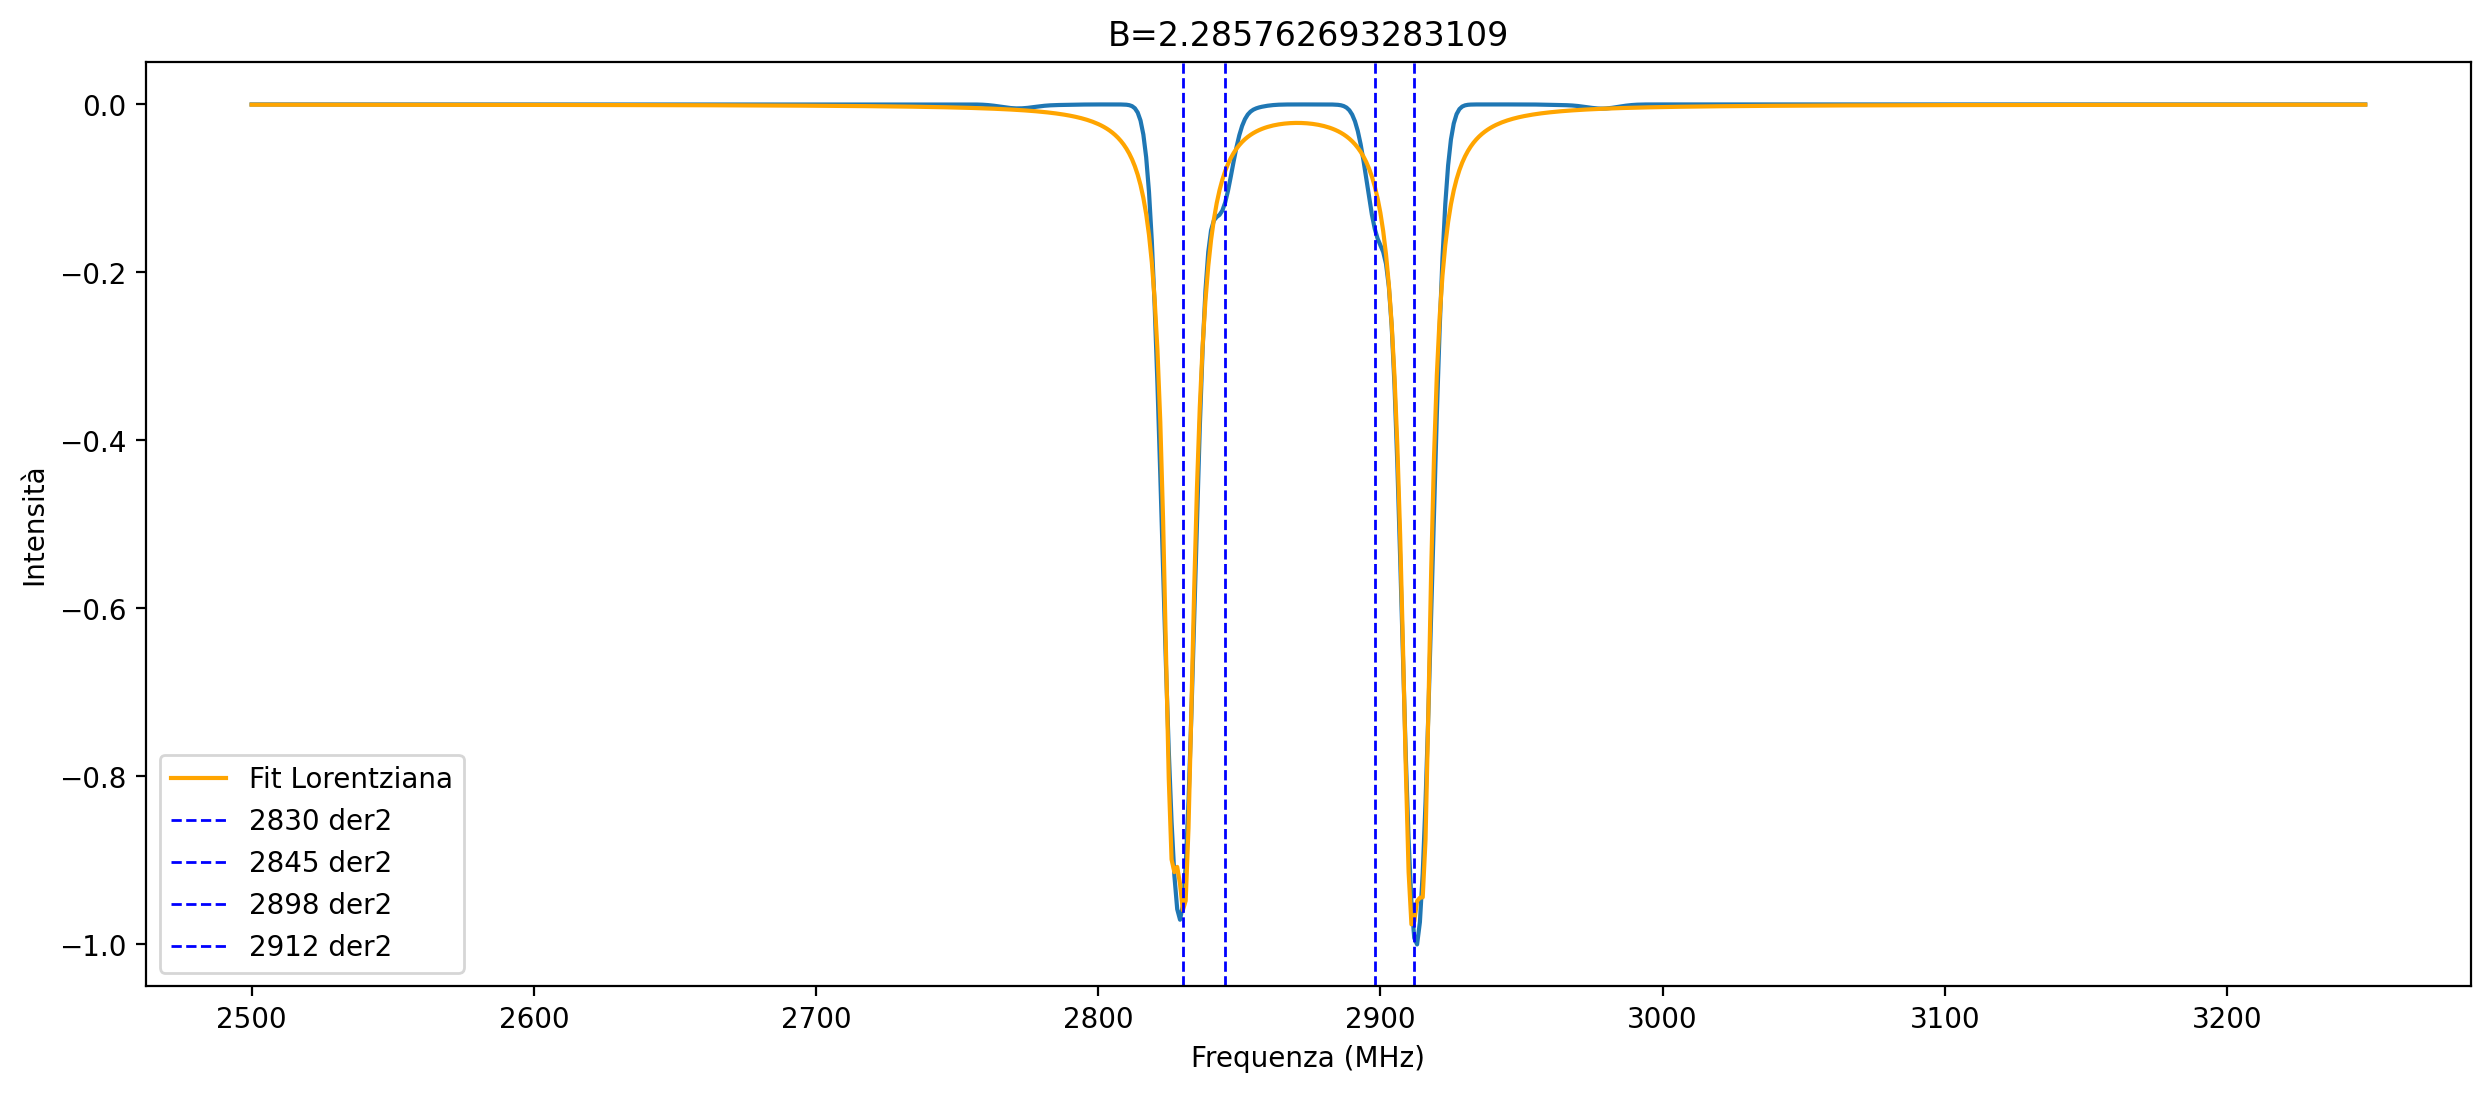

In [ ]:
plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, s[2])
plt.plot(x_axis, -multi_lorentziana(f, amp_2_der2_opt, pos_2_der2_opt, gamma_2_der2_opt), color='orange', label='Fit Lorentziana')
for pos in pos_der2:
    plt.axvline(x=pos, color='blue', linestyle='--', label=f'{pos} der2', linewidth=1)  # Evidenziamo i picchi con linee verticali
plt.title(f"B={B[2]}")
plt.xlabel('Frequenza (MHz)')
plt.ylabel('Intensità')
plt.legend()
plt.show()

In [ ]:
# stampo i parametri ottimizzati
print("Ampiezze ottimizzate:", amp_2_der2_opt)
print("Posizioni ottimizzate:", pos_2_der2_opt)
print("Gamma ottimizzati:", gamma_2_der2_opt)

Ampiezze ottimizzate: [3.15223441 1.87392581 3.31507063 1.76027917]
Posizioni ottimizzate: [2830.96234918 2825.78491367 2910.70049047 2915.60990387]
Gamma ottimizzati: [4.01408598 3.18545847 4.13408187 3.04333927]


---

per tutti gli spettri

In [ ]:
n_dip_per_spettro = np.zeros(N_spettri, dtype=int)
pos_dip_per_spettro = np.zeros((N_spettri, 8))  # Supponiamo un massimo di 8 dip per spettro  

for n in range(N_spettri):
    spettro_corrente = s[n]
    ds_df = np.gradient(spettro_corrente, f)
    d2s_df2 = np.gradient(ds_df, f)
    pos_der2, info_der2 = trova_picchi_scipy(f, d2s_df2, soglia=0.001)
    # Salva o visualizza i risultati come necessario
    
    n_dip_per_spettro[n] = len(pos_der2)
    pos_dip_per_spettro[n, :len(pos_der2)] = pos_der2

In [ ]:
for idx, n in enumerate(n_dip_per_spettro):
    #if n % 2 != 0:
    if n==5:
        print(idx, n)

8 5
9 5
10 5
11 5
12 5
19 5
23 5
38 5
56 5
65 5
68 5
74 5
94 5
114 5
121 5
134 5
139 5
153 5
166 5
167 5
190 5
205 5
225 5
244 5
250 5
259 5
296 5
309 5
312 5
333 5
340 5
347 5
349 5
367 5
368 5
385 5
415 5
424 5
431 5
433 5
463 5
483 5
506 5
526 5
527 5
541 5
571 5
579 5
583 5
598 5
602 5
607 5
611 5
629 5
650 5
670 5
678 5
683 5
684 5
692 5
710 5
799 5
813 5
831 5
844 5
851 5
900 5
907 5
910 5
935 5
936 5
955 5
956 5
973 5
996 5
1017 5
1045 5
1050 5
1052 5
1066 5
1069 5
1070 5
1072 5
1091 5
1119 5
1153 5
1163 5
1172 5
1176 5
1205 5
1207 5
1217 5
1225 5
1230 5
1252 5
1273 5
1274 5
1280 5
1289 5
1295 5
1302 5
1307 5
1308 5
1318 5
1362 5
1375 5
1378 5
1395 5
1407 5
1414 5
1427 5
1449 5
1466 5
1477 5
1480 5
1524 5
1534 5
1536 5
1573 5
1574 5
1575 5
1598 5
1607 5
1613 5
1625 5
1628 5
1632 5
1635 5
1653 5
1659 5
1673 5
1691 5
1702 5
1718 5
1734 5
1759 5
1767 5
1770 5
1778 5
1780 5
1807 5
1824 5
1853 5
1875 5
1887 5
1893 5
1904 5
1910 5
1915 5
1918 5
1929 5
1961 5
1963 5
1970 5
1971 5
1985 